# QM9 EDA + Visualizacion 3D

Notebook inicial para revisar y analizar tu dataset local QM9 (`.xyz` extendido) y visualizar moleculas en 3D.

Este notebook:
- Usa tus archivos locales en `data/archive`.
- Evita duplicados cuando existen dos rutas para la misma molecula.
- Parsea propiedades QM9, geometria y metadatos.
- Crea una tabla para EDA.
- Permite visualizar moleculas en 3D con `py3Dmol`.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _HAS_SEABORN = True
except ImportError:
    _HAS_SEABORN = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

ROOT = Path.cwd()
if ROOT.name != "QM9" and (ROOT / "QM9").exists():
    ROOT = ROOT / "QM9"

ARCHIVE = ROOT / "data" / "archive"
ARCHIVE_NESTED = ARCHIVE / "dsgdb9nsd.xyz"

ROOT, ARCHIVE, ARCHIVE.exists()

(PosixPath('/home/colmanok/Code/QM9'),
 PosixPath('/home/colmanok/Code/QM9/data/archive'),
 True)

In [2]:
PROPERTY_KEYS = [
    "A", "B", "C", "mu", "alpha", "homo", "lumo", "gap", "r2", "zpve", "U0", "U", "H", "G", "Cv"
]
ATOM_Z = {"H": 1, "C": 6, "N": 7, "O": 8, "F": 9}


def to_float_qm9(token: str) -> float:
    """QM9 a veces usa notacion tipo Mathematica: 2.1997*^-6 -> 2.1997e-6."""
    return float(token.replace("*^", "e"))


def parse_qm9_xyz(path: Path) -> Dict[str, Any]:
    lines = [ln.strip() for ln in path.read_text().splitlines() if ln.strip()]
    n_atoms = int(lines[0])

    header = lines[1].split()
    if header[0].lower() != "gdb":
        raise ValueError(f"Formato inesperado (linea 2) en {path}")

    mol_id = int(header[1])
    prop_values = [to_float_qm9(v) for v in header[2:]]
    if len(prop_values) != len(PROPERTY_KEYS):
        raise ValueError(f"Se esperaban {len(PROPERTY_KEYS)} propiedades, llegaron {len(prop_values)} en {path}")
    props = dict(zip(PROPERTY_KEYS, prop_values))

    atom_lines = lines[2:2 + n_atoms]
    symbols: List[str] = []
    z: List[int] = []
    pos: List[List[float]] = []
    partial_charges: List[float] = []
    for al in atom_lines:
        s, x, y, zc, q = al.split()
        symbols.append(s)
        z.append(ATOM_Z[s])
        pos.append([to_float_qm9(x), to_float_qm9(y), to_float_qm9(zc)])
        partial_charges.append(to_float_qm9(q))

    rest = lines[2 + n_atoms:]
    freqs: List[float] = []
    smiles = None
    inchi = None

    for ln in rest:
        if ln.startswith("InChI="):
            inchi = ln.split()[0]
            continue
        parts = ln.split()
        try:
            freqs.extend(to_float_qm9(v) for v in parts)
        except ValueError:
            smiles = parts[0] if parts else None

    n_by_element = {f"n_{el}": symbols.count(el) for el in ["H", "C", "N", "O", "F"]}

    out: Dict[str, Any] = {
        "path": str(path),
        "mol_id": mol_id,
        "n_atoms": n_atoms,
        "symbols": symbols,
        "z": z,
        "pos": pos,
        "partial_charges": partial_charges,
        "freqs": freqs,
        "n_freqs": len(freqs),
        "smiles": smiles,
        "inchi": inchi,
    }
    out.update(n_by_element)
    out.update(props)
    return out

In [3]:
# Detectar archivos y elegir una fuente principal para evitar duplicados
top_files = sorted(ARCHIVE.glob("dsgdb9nsd_*.xyz")) if ARCHIVE.exists() else []
nested_files = sorted(ARCHIVE_NESTED.glob("dsgdb9nsd_*.xyz")) if ARCHIVE_NESTED.exists() else []

print(f"Top-level files: {len(top_files):,}")
print(f"Nested files   : {len(nested_files):,}")

if nested_files:
    selected_files = nested_files
    source_name = "nested (data/archive/dsgdb9nsd.xyz)"
elif top_files:
    selected_files = top_files
    source_name = "top-level (data/archive)"
else:
    selected_files = []
    source_name = "none"

print(f"Selected source: {source_name}")
print(f"Files to parse : {len(selected_files):,}")

Top-level files: 133,885
Nested files   : 133,885
Selected source: nested (data/archive/dsgdb9nsd.xyz)
Files to parse : 133,885


In [4]:
# Probar parser en un ejemplo
example = parse_qm9_xyz(selected_files[0])
print("Sample path:", example["path"])
print("mol_id:", example["mol_id"])
print("n_atoms:", example["n_atoms"])
print("U0, U (raw units from file):", example["U0"], example["U"])
print("SMILES:", example["smiles"])
print("InChI:", example["inchi"])
print("symbols:", example["symbols"])
print("first coord:", example["pos"][0])

Sample path: /home/colmanok/Code/QM9/data/archive/dsgdb9nsd.xyz/dsgdb9nsd_000001.xyz
mol_id: 1
n_atoms: 5
U0, U (raw units from file): -40.47893 -40.476062
SMILES: C
InChI: InChI=1S/CH4/h1H4
symbols: ['C', 'H', 'H', 'H', 'H']
first coord: [-0.0126981359, 1.0858041578, 0.0080009958]


In [5]:
# Parseo masivo (usa MAX_FILES=None para todo el dataset)
MAX_FILES = 20000  # cambia a None para usar todos

to_parse = selected_files if MAX_FILES is None else selected_files[:MAX_FILES]
records = []
for i, fp in enumerate(to_parse, 1):
    try:
        records.append(parse_qm9_xyz(fp))
    except Exception as e:
        print(f"[WARN] Error parseando {fp.name}: {e}")
    if i % 10000 == 0:
        print(f"Parsed {i:,} files...")

df = pd.DataFrame(records)
print("Parsed rows:", len(df))
print("Columns:", len(df.columns))
df.head(3)

Parsed 10,000 files...
Parsed 20,000 files...
Parsed rows: 20000
Columns: 31


,path,mol_id,n_atoms,symbols,z,pos,partial_charges,freqs,n_freqs,smiles,inchi,n_H,n_C,n_N,n_O,n_F,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,U0,U,H,G,Cv
0,/home/colmanok/Code/QM9/data/archive/dsgdb9nsd...,1,5,"[C, H, H, H, H]","[6, 1, 1, 1, 1]","[[-0.0126981359, 1.0858041578, 0.0080009958], ...","[-0.535689, 0.133921, 0.133922, 0.133923, 0.13...","[1341.307, 1341.3284, 1341.365, 1562.6731, 156...",9,C,InChI=1S/CH4/h1H4,4,1,0,0,0,157.71180,157.70997,157.70699,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469
1,/home/colmanok/Code/QM9/data/archive/dsgdb9nsd...,2,4,"[N, H, H, H]","[7, 1, 1, 1]","[[-0.0404260543, 1.0241077531, 0.0625637998], ...","[-0.707143, 0.235712, 0.235712, 0.23572]","[1103.8733, 1684.1158, 1684.3072, 3458.7145, 3...",6,N,InChI=1S/H3N/h1H3,3,0,1,0,0,293.60975,293.54111,191.39397,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316
2,/home/colmanok/Code/QM9/data/archive/dsgdb9nsd...,3,3,"[O, H, H]","[8, 1, 1]","[[-0.0343604951, 0.9775395708, 0.0076015923], ...","[-0.589706, 0.294853, 0.294853]","[1671.4222, 3803.6305, 3907.698]",3,O,InChI=1S/H2O/h1H2,2,0,0,1,0,799.58812,437.90386,282.94545,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002


,count,mean,std,min,25%,50%,75%,max
n_atoms,20000.0,16.315250,2.843795,3.000000,14.000000,16.000000,18.000000,26.000000
U0,20000.0,-362.638480,38.888969,-492.026657,-384.955686,-363.846052,-345.293940,-40.478930
U,20000.0,-362.630769,38.888654,-492.019416,-384.947687,-363.838618,-345.287685,-40.476062
H,20000.0,-362.629825,38.888654,-492.018471,-384.946743,-363.837674,-345.286741,-40.475117
G,20000.0,-362.670714,38.889623,-492.058075,-384.988269,-363.878335,-345.324072,-40.498597
gap,20000.0,0.262394,0.047429,0.076600,0.224200,0.263600,0.301200,0.622100
mu,20000.0,2.542296,1.457239,0.000000,1.486275,2.327700,3.485175,18.691500
Cv,20000.0,28.287757,4.052628,6.002000,25.728500,28.330000,30.960000,42.103000
n_C,20000.0,5.619500,1.153944,0.000000,5.000000,6.000000,6.000000,8.000000
n_H,20000.0,8.566950,2.651522,0.000000,7.000000,8.000000,10.000000,18.000000


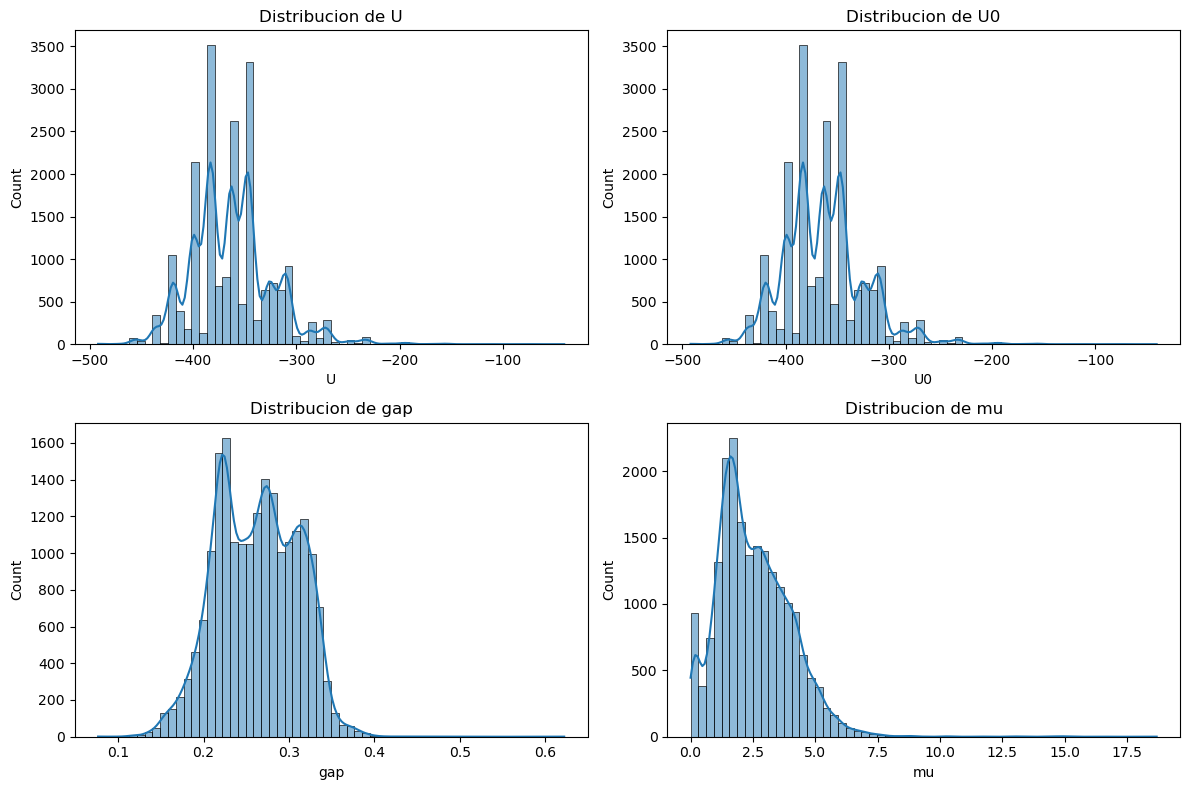

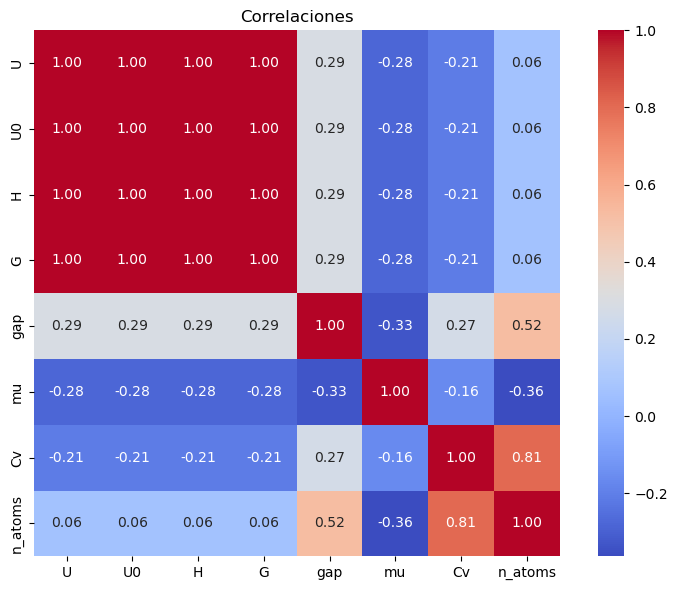

In [6]:
# EDA rapido
eda_cols = ["n_atoms", "U0", "U", "H", "G", "gap", "mu", "Cv", "n_C", "n_H", "n_N", "n_O", "n_F", "n_freqs"]
display(df[eda_cols].describe().T)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, ["U", "U0", "gap", "mu"]):
    if _HAS_SEABORN:
        sns.histplot(df[col], bins=60, kde=True, ax=ax)
    else:
        ax.hist(df[col], bins=60)
    ax.set_title(f"Distribucion de {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

corr = df[["U", "U0", "H", "G", "gap", "mu", "Cv", "n_atoms"]].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
if _HAS_SEABORN:
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
else:
    plt.imshow(corr, cmap="coolwarm")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar()
plt.title("Correlaciones")
plt.tight_layout()
plt.show()

In [7]:
def xyz_string(symbols: List[str], coords: List[List[float]], comment: str = "QM9 molecule") -> str:
    lines = [str(len(symbols)), comment]
    for s, (x, y, z) in zip(symbols, coords):
        lines.append(f"{s} {x:.8f} {y:.8f} {z:.8f}")
    return "\n".join(lines)

def show_3d(symbols: List[str], coords: List[List[float]], style: str = "stick", width: int = 640, height: int = 420):
    try:
        import py3Dmol
    except ImportError as e:
        raise ImportError(
            "py3Dmol no instalado. Ejecuta: pip install py3Dmol"
        ) from e

    xyz = xyz_string(symbols, coords)
    view = py3Dmol.view(width=width, height=height)
    view.addModel(xyz, "xyz")
    if style == "sphere":
        view.setStyle({"sphere": {"scale": 0.3}})
    elif style == "ballstick":
        view.setStyle({"stick": {}, "sphere": {"scale": 0.25}})
    else:
        view.setStyle({"stick": {}})
    view.zoomTo()
    return view.show()

In [8]:
# Visualizacion 3D de ejemplo
# Puedes cambiar idx por cualquier fila de df
idx = 10
row = df.iloc[idx]
print("Molecule:", row["mol_id"], "| atoms:", row["n_atoms"], "| U:", row["U"], "| smiles:", row["smiles"])
show_3d(row["symbols"], row["pos"], style="ballstick")

Molecule: 11 | atoms: 7 | U: -153.783728 | smiles: CC=O


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [11]:
import os
from pathlib import Path

# 📁 ruta absoluta correcta
base_path = Path("/home/colmanok/Code/QM9/data/archive")

folder_main = base_path
folder_nested = base_path / "dsgdb9nsd.xyz"

# 🔍 verificar rutas
print("=== DEBUG RUTAS ===")
print("archive existe:", folder_main.exists())
print("nested existe:", folder_nested.exists())
print("nested es carpeta:", folder_nested.is_dir())
print("nested es archivo:", folder_nested.is_file())

# 📂 obtener archivos .xyz
def get_xyz_files(folder):
    if not folder.exists():
        print(f"⚠️ Carpeta no existe: {folder}")
        return set()
    
    return set(f.name for f in folder.glob("*.xyz"))

main_files = get_xyz_files(folder_main)

# ⚠️ solo leer nested si es carpeta
if folder_nested.is_dir():
    nested_files = get_xyz_files(folder_nested)
else:
    print("\n⚠️ dsgdb9nsd.xyz NO es carpeta, es un archivo")
    nested_files = set()

# 🔍 comparación básica
only_in_main = main_files - nested_files
only_in_nested = nested_files - main_files
in_both = main_files & nested_files

# 📊 resultados
print("\n📊 RESUMEN")
print(f"En archive/: {len(main_files)}")
print(f"En dsgdb9nsd.xyz/: {len(nested_files)}")
print(f"En ambos: {len(in_both)}")
print(f"Solo en archive/: {len(only_in_main)}")
print(f"Solo en nested: {len(only_in_nested)}")

# 🧾 ejemplos
print("\nEjemplos solo en archive:")
print(list(only_in_main)[:5])

print("\nEjemplos solo en nested:")
print(list(only_in_nested)[:5])

=== DEBUG RUTAS ===
archive existe: True
nested existe: True
nested es carpeta: True
nested es archivo: False

📊 RESUMEN
En archive/: 133886
En dsgdb9nsd.xyz/: 133885
En ambos: 133885
Solo en archive/: 1
Solo en nested: 0

Ejemplos solo en archive:
['dsgdb9nsd.xyz']

Ejemplos solo en nested:
[]


In [12]:
from pathlib import Path

base_path = Path("/home/colmanok/Code/QM9/data/archive")
folder_main = base_path
folder_nested = base_path / "dsgdb9nsd.xyz"

def files_are_equal(f1, f2):
    with open(f1, 'r') as a, open(f2, 'r') as b:
        return a.read() == b.read()

# obtener intersección (ya sabes que son 133885)
common_files = set(f.name for f in folder_main.glob("*.xyz")) & \
               set(f.name for f in folder_nested.glob("*.xyz"))

different = []

for i, fname in enumerate(common_files):
    f1 = folder_main / fname
    f2 = folder_nested / fname

    if not files_are_equal(f1, f2):
        different.append(fname)

    # progreso cada cierto tiempo
    if i % 10000 == 0:
        print(f"Procesados: {i}")

print("\n📊 RESULTADO FINAL")
print("Archivos diferentes:", len(different))

if different:
    print("Ejemplos:", different[:5])
else:
    print("✅ Todos los archivos son idénticos")

Procesados: 0
Procesados: 10000
Procesados: 20000
Procesados: 30000
Procesados: 40000
Procesados: 50000
Procesados: 60000
Procesados: 70000
Procesados: 80000
Procesados: 90000
Procesados: 100000
Procesados: 110000
Procesados: 120000
Procesados: 130000

📊 RESULTADO FINAL
Archivos diferentes: 0
✅ Todos los archivos son idénticos
